# Evaluation

#### Code Block: Imports, Helpers, and Reusable Utilities

In [7]:
import os
import gc
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
from torch.utils.data import DataLoader

from sklearn.manifold import TSNE
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, roc_curve, auc

from config import ExperimentConfig
from dataset import WhaleDataset, build_dataloaders, build_train_transform, build_val_transform, prepare_data
from models import build_model
from evaluation import extract_embeddings, evaluate_retrieval

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 130
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

device = torch.device(
    "cuda" if torch.cuda.is_available() else
    "mps" if hasattr(torch.backends, "mps") and torch.backends.mps.is_available() else
    "cpu"
)
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD = np.array([0.229, 0.224, 0.225], dtype=np.float32)
BIN_ORDER = ["1 image", "2-5 images", "6-10 images", "11+ images"]


def cleanup_memory(*names, scope=None):
    if scope is None:
        scope = globals()
    for n in names:
        if n in scope:
            del scope[n]
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


def tensor_to_image(tensor):
    """Undo normalization for visualization."""
    arr = tensor.detach().cpu().numpy().transpose(1, 2, 0)
    arr = np.clip(arr * IMAGENET_STD + IMAGENET_MEAN, 0.0, 1.0)
    return arr


def n_shot_bin(n):
    if n == 1:
        return "1 image"
    if 2 <= n <= 5:
        return "2-5 images"
    if 6 <= n <= 10:
        return "6-10 images"
    return "11+ images"


def build_retrieval_eval_loaders(config, data):
    image_dir = os.path.join(config.data_dir, "train")
    eval_transform = build_val_transform(config)

    gallery_dataset = WhaleDataset(
        df=data["train_df"],
        image_dir=image_dir,
        id_to_idx=data["id_to_idx"],
        transform=eval_transform,
    )
    query_dataset = WhaleDataset(
        df=data["val_df"],
        image_dir=image_dir,
        id_to_idx=data["id_to_idx"],
        transform=eval_transform,
    )

    batch_size = config.batch_size * 2
    gallery_loader = DataLoader(
        gallery_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=config.num_workers,
        pin_memory=True,
        drop_last=False,
    )
    query_loader = DataLoader(
        query_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=config.num_workers,
        pin_memory=True,
        drop_last=False,
    )
    return gallery_loader, query_loader


def compute_top1_predictions(model, gallery_loader, query_loader, idx_to_class_count, device, chunk_size=256):
    if model is None:
        return None

    gallery_emb, gallery_labels = extract_embeddings(model, gallery_loader, device)
    query_emb, query_labels = extract_embeddings(model, query_loader, device)

    known_gallery = gallery_labels >= 0
    gallery_emb = gallery_emb[known_gallery]
    gallery_labels = gallery_labels[known_gallery]

    if gallery_emb.size(0) == 0:
        return pd.DataFrame()

    records = []
    for start in range(0, len(query_emb), chunk_size):
        end = min(start + chunk_size, len(query_emb))
        q = query_emb[start:end]
        q_labels = query_labels[start:end]

        sims = q @ gallery_emb.t()
        top_sim, top_idx = sims.max(dim=1)
        pred_labels = gallery_labels[top_idx]

        for i in range(len(q)):
            true_label = int(q_labels[i].item())
            pred_label = int(pred_labels[i].item())
            max_similarity = float(top_sim[i].item())
            is_known = true_label >= 0
            class_size = idx_to_class_count.get(true_label, 0) if is_known else 0

            records.append({
                "true_label": true_label,
                "pred_label": pred_label,
                "max_similarity": max_similarity,
                "is_known": is_known,
                "is_new_whale": true_label == -1,
                "class_size": class_size,
                "n_shot_bin": n_shot_bin(class_size) if is_known else "new_whale",
                "is_correct": bool(is_known and (pred_label == true_label)),
            })

    return pd.DataFrame(records)


def summarize_model_predictions(pred_df, threshold=0.5):
    if pred_df is None or len(pred_df) == 0:
        return {}

    known_df = pred_df[pred_df["is_known"]]

    metrics = {
        "n_queries": int(len(pred_df)),
        "n_known_queries": int(pred_df["is_known"].sum()),
        "n_new_queries": int((~pred_df["is_known"]).sum()),
    }

    if len(known_df) > 0:
        y_true_known = known_df["true_label"].values
        y_pred_known = known_df["pred_label"].values
        metrics["known_accuracy"] = float(accuracy_score(y_true_known, y_pred_known))
        metrics["known_f1_weighted"] = float(f1_score(y_true_known, y_pred_known, average="weighted", zero_division=0))
        metrics["known_f1_macro"] = float(f1_score(y_true_known, y_pred_known, average="macro", zero_division=0))
    else:
        metrics["known_accuracy"] = np.nan
        metrics["known_f1_weighted"] = np.nan
        metrics["known_f1_macro"] = np.nan

    y_true_new = (~pred_df["is_known"]).astype(int).values  # 1 if new whale
    y_score_new = -pred_df["max_similarity"].values          # higher means more likely new
    y_pred_new = (pred_df["max_similarity"] < threshold).astype(int).values

    metrics["open_set_accuracy"] = float(accuracy_score(y_true_new, y_pred_new))
    metrics["new_whale_recall"] = float(((y_pred_new == 1) & (y_true_new == 1)).sum() / max((y_true_new == 1).sum(), 1))
    metrics["new_whale_f1"] = float(f1_score(y_true_new, y_pred_new, zero_division=0))

    if len(np.unique(y_true_new)) >= 2:
        metrics["open_set_auc"] = float(roc_auc_score(y_true_new, y_score_new))
    else:
        metrics["open_set_auc"] = np.nan

    return metrics


def plot_embedding_tsne(model, loader, data, device, title="", max_samples=700, top_k_classes=10, min_samples_per_class=5):
    """t-SNE style aligned with notebook 02: top frequent classes + centroid labels."""
    if model is None:
        print(f"[skip] {title}: model is missing.")
        return

    emb_t, lab_t = extract_embeddings(model, loader, device)
    emb = emb_t.cpu().numpy()
    lab = lab_t.cpu().numpy()

    known_mask = lab >= 0
    emb = emb[known_mask]
    lab = lab[known_mask]

    if len(emb) < 30:
        print(f"[skip] {title}: too few known samples.")
        return

    unique, counts = np.unique(lab, return_counts=True)
    frequent = unique[counts >= min_samples_per_class]
    if len(frequent) == 0:
        frequent = unique[counts >= 2]
    if len(frequent) == 0:
        print(f"[skip] {title}: no classes with enough samples.")
        return

    freq_counts = {c: int(counts[unique == c][0]) for c in frequent}
    top_classes = sorted(freq_counts, key=freq_counts.get, reverse=True)[:top_k_classes]

    class_mask = np.isin(lab, top_classes)
    emb = emb[class_mask]
    lab = lab[class_mask]

    if len(emb) > max_samples:
        rng = np.random.default_rng(42)
        idx = rng.choice(len(emb), size=max_samples, replace=False)
        emb = emb[idx]
        lab = lab[idx]

    if len(np.unique(lab)) < 2:
        print(f"[skip] {title}: t-SNE needs at least 2 classes.")
        return

    perplexity = min(max(len(emb) // 8, 5), 50)
    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        random_state=42,
        max_iter=1500,
        init="pca",
        learning_rate="auto",
    )
    emb_2d = tsne.fit_transform(emb)

    plt.figure(figsize=(9.5, 9.0))
    cmap = plt.cm.get_cmap("tab10" if len(np.unique(lab)) <= 10 else "tab20")
    classes_sorted = sorted(np.unique(lab))

    for i, c in enumerate(classes_sorted):
        mask = lab == c
        color = cmap(i % cmap.N)
        whale_name = data["idx_to_id"].get(int(c), str(c))

        plt.scatter(
            emb_2d[mask, 0], emb_2d[mask, 1],
            s=48,
            alpha=0.82,
            color=color,
            edgecolors="white",
            linewidths=0.3,
            label=f"{whale_name[:10]} ({mask.sum()})",
        )

        cx, cy = emb_2d[mask, 0].mean(), emb_2d[mask, 1].mean()
        plt.annotate(
            whale_name[:10],
            (cx, cy),
            fontsize=8,
            xytext=(4, 3),
            textcoords="offset points",
            bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7),
        )

    plt.title(title or "t-SNE of validation embeddings", fontsize=14)
    plt.xlabel("t-SNE component 1")
    plt.ylabel("t-SNE component 2")
    plt.grid(alpha=0.22)
    plt.legend(fontsize=8, frameon=True, loc="best", ncol=2)
    plt.tight_layout()
    plt.show()

Device: cpu


### Interpretation Guide: Dataset Distribution Plots

What this figure set shows:
1. **Left panel:** how many known identities fall into each N-shot bin.
2. **Right panel:** frequency-rank profile on log-log axes (long-tail diagnostics).

### Long-tail in plain language
- Imagine listing identities from most common to rarest.
- Rank `1` is the most photographed whale, rank `2` is the next, and so on.
- If the dataset is long-tail, a few identities have many images, while most identities have very few.


### Why log-log axes are used
- On a normal axis, very large values dominate and small values get visually squashed.
- A log axis turns multiplicative steps into equal visual steps:
  - Moving from `1` to `10` to `100` is evenly spaced.
- So log-log makes it easier to see both head classes and tail classes in one view.


### How to read slope on log-log
- A roughly straight descending segment means heavy-tail behavior.
- Steeper slope means frequency drops faster as rank increases (more imbalance).
- Flatter slope means slower decay (less extreme imbalance).
- Intuition: if rank doubles and frequency roughly halves repeatedly, you get a stable downward trend.


### How to connect this to model behavior
- Many classes in `1` and `2-5` bins means most classes are low-data.
- Low-data classes are where standard classification often struggles.
- Margin-based or metric-learning-style objectives may help, but only if the supervision signal fits the data regime.


Notes for next AI reviewer:
- If later metric-learning gains are concentrated in low-shot bins, this plot gives the data-regime reason.
- If gains happen only in high-shot bins, investigate objective mismatch with long-tail constraints.
- If open-set thresholding is unstable, verify whether the tail amplifies score variance in rare classes.

#### Code Block: Build Dataset Statistics and Plot Long-tail Curves

## Experimental Roadmap and Model Differences

All three approaches share the same backbone family and image preprocessing protocol. They differ in what supervision signal trains the representation.

### Taxonomy clarification (important for report wording)
- **Baseline** is standard multi-class classification.
- **ArcFace is also classification**, not pairwise metric learning in the strict triplet/contrastive sense.
- ArcFace modifies the classification logits with an additive angular margin, so it is best described as a **margin-based classifier with embedding-aware geometry**.
- **Triplet Loss is true metric learning** because it directly optimizes relative distances between anchor/positive/negative examples.

| Method | What it really is | Core objective | Similarities with others | Key difference | Pre-analysis expectation |
|---|---|---|---|---|---|
| **Baseline (Softmax + Focal)** | Classic classifier | Multi-class classification with class-imbalance handling | Same backbone, same input size, same train/val split | No explicit metric margin in embedding space | Stronger on well-represented classes, weaker in 1-shot regime |
| **ArcFace** | Margin-based classifier | Classification with additive angular margin on normalized embeddings | Still classification-based training; uses same identities and images | Enforces angular separation directly in logits | Improved few-shot retrieval and stronger positive/negative separation |
| **Triplet Loss (semi-hard)** | Metric-learning objective | Pairwise metric optimization with anchor-positive-negative tuples | Same embedding extractor and evaluation protocol | Requires valid anchor-positive pairs; singleton classes cannot form pairs | Better embedding compactness where pair sampling is feasible; potential weakness on 1-shot identities |

This section defines expected behavior before inspecting final numbers.

#### Code Block: Build Shared Evaluation Protocol

In [ ]:
retrieval_eval_config = ExperimentConfig(
    data_dir="data",
    seed=42,
    stratified_split=True,
    include_new_whale_in_val=True,
    batch_size=12,
    num_workers=2,
    confidence_threshold=0.5,
)

data = prepare_data(retrieval_eval_config)
gallery_loader, query_loader = build_retrieval_eval_loaders(retrieval_eval_config, data)

train_class_counts = data["train_df"]["Id"].value_counts().to_dict()
idx_to_class_count = {
    idx: int(train_class_counts.get(whale_id, 0))
    for idx, whale_id in data["idx_to_id"].items()
}

train_bin_counts = pd.Series({
    "1 image": int(sum(v == 1 for v in idx_to_class_count.values())),
    "2-5 images": int(sum(2 <= v <= 5 for v in idx_to_class_count.values())),
    "6-10 images": int(sum(6 <= v <= 10 for v in idx_to_class_count.values())),
    "11+ images": int(sum(v >= 11 for v in idx_to_class_count.values())),
}).reindex(BIN_ORDER)

protocol_df = pd.DataFrame([
    {"Setting": "Open-set threshold", "Value": retrieval_eval_config.confidence_threshold},
    {"Setting": "Gallery split", "Value": "train_df"},
    {"Setting": "Query split", "Value": "val_df"},
    {"Setting": "Known identities in train split", "Value": len(idx_to_class_count)},
    {
        "Setting": "1-shot identity ratio (train split)",
        "Value": f"{100.0 * train_bin_counts['1 image'] / max(len(idx_to_class_count), 1):.2f}%",
    },
])

display(protocol_df)
display(pd.DataFrame({"N-shot bin": BIN_ORDER, "Train identities": train_bin_counts.values}))

predictions_by_model = {}
retrieval_metrics_by_model = {}
print("Evaluation protocol ready. Next: load checkpoints and evaluate Baseline -> ArcFace -> Triplet.")

[split] Stratified test split infeasible on frequent classes; using shuffled split.
[split] Stratified val split infeasible on frequent classes; using shuffled split.
Dataset split:
  Train:    8089 images, 4247 known classes (filtered 647 new_whale)
  Val:       557 images (88 are new_whale)
  Test:      557 images (75 are new_whale)
  Class distribution: min=1 median=1 max=24 samples/class


,Setting,Value
0,Retrieval k,5
1,Open-set threshold,0.5
2,Gallery split,train_df
3,Query split,val_df
4,Known identities in train split,4247
5,1-shot identity ratio (train split),53.59%


,N-shot bin,Train identities
0,1 image,2276
1,2-5 images,1829
2,6-10 images,101
3,11+ images,41


Evaluation protocol ready. Next: load checkpoints and evaluate Baseline -> ArcFace -> Triplet.


## Section 3: Evaluate models

### Load models

model.safetensors:   0%|          | 0.00/122M [00:00<?, ?B/s]

c:\Users\krios\Documents\Kode\Unibo\ML4CV\.venv\Lib\site-packages\huggingface_hub\file_download.py:130: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\krios\.cache\huggingface\hub\models--timm--efficientnet_b5.sw_in12k_ft_in1k. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


[ok] Baseline loaded from experiments\20260402_175215_baseline_effnetb5_focal_bd5dccca\checkpoints\best.pth
Loading backbone + embedding from: experiments/20260402_175215_baseline_effnetb5_focal_bd5dccca/checkpoints/best.pth
  Loaded 859 parameter tensors (backbone + embedding)
[ok] ArcFace loaded from experiments\20260403_163615_arcface_effnetb5_6c8d152f\checkpoints\best.pth
Loading backbone + embedding from: experiments/20260402_175215_baseline_effnetb5_focal_bd5dccca/checkpoints/best.pth
  Loaded 859 parameter tensors (backbone + embedding)
[ok] Triplet loaded from experiments\20260404_143337_triplet_effnetb5_3ae3db53\checkpoints\best.pth
Available models: ['Baseline', 'ArcFace', 'Triplet']


c:\Users\krios\Documents\Kode\Unibo\ML4CV\.venv\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


  Extracting embeddings:   0%|          | 0/338 [00:16<?, ?it/s]

  Extracting embeddings:   0%|          | 0/24 [00:15<?, ?it/s]

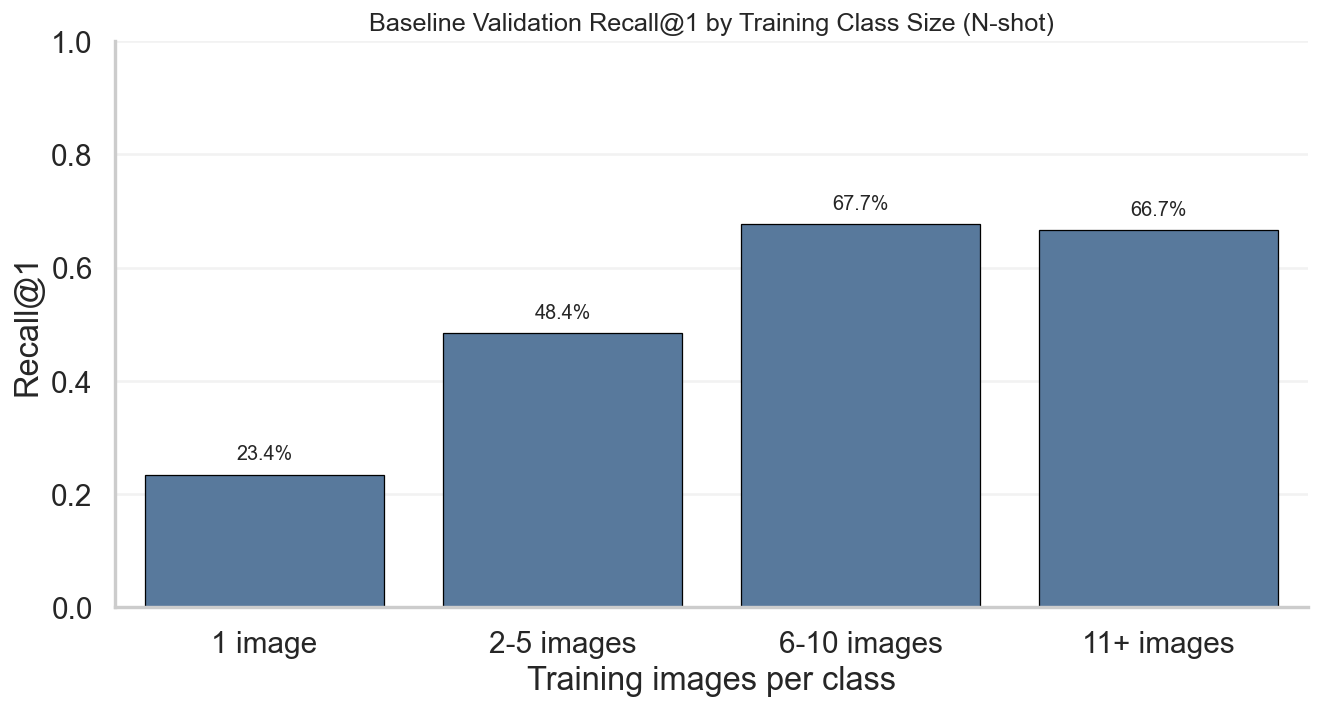

,n_shot_bin,recall_at_1
0,1 image,0.234375
1,2-5 images,0.484321
2,6-10 images,0.677419
3,11+ images,0.666667


,Metric,Baseline
0,n_queries,557.000000
1,n_known_queries,467.000000
2,n_new_queries,90.000000
3,known_accuracy,0.496788
4,known_f1_weighted,0.500255
5,known_f1_macro,0.343138
6,open_set_accuracy,0.838420
7,new_whale_recall,0.000000
8,new_whale_f1,0.000000
9,open_set_auc,0.494730


<Figure size 832x624 with 0 Axes>

In [ ]:
def latest_experiment_by_keyword(keyword):
    exp_root = Path("experiments")
    if not exp_root.exists():
        return None
    candidates = [d for d in exp_root.iterdir() if d.is_dir() and keyword in d.name.lower()]
    candidates = [d for d in candidates if (d / "checkpoints" / "best.pth").exists()]
    if not candidates:
        return None
    return sorted(candidates, key=lambda p: p.name)[-1]


def load_trained_model(exp_dir, model_name):
    if exp_dir is None:
        print(f"[warning] No experiment directory found for {model_name}.")
        return None, None, None

    config_path = exp_dir / "config.json"
    ckpt_path = exp_dir / "checkpoints" / "best.pth"

    if not config_path.exists() or not ckpt_path.exists():
        print(f"[warning] Missing config/checkpoint for {model_name} at {exp_dir}.")
        return None, None, None

    try:
        cfg = ExperimentConfig.load(str(config_path))
        model = build_model(cfg, data["num_classes"], device)
        state = torch.load(ckpt_path, map_location=device, weights_only=False)
        model_state = state.get("model_state_dict", state)
        model.load_state_dict(model_state)
        model.eval()
        print(f"[ok] {model_name} loaded from {ckpt_path}")
        return model, cfg, ckpt_path
    except Exception as e:
        print(f"[warning] Could not load {model_name}: {e}")
        return None, None, None


baseline_dir = latest_experiment_by_keyword("baseline")
arcface_dir = latest_experiment_by_keyword("arcface")
triplet_dir = latest_experiment_by_keyword("triplet")

baseline_model, baseline_cfg, baseline_ckpt = load_trained_model(baseline_dir, "Baseline")
arcface_model, arcface_cfg, arcface_ckpt = load_trained_model(arcface_dir, "ArcFace")
triplet_model, triplet_cfg, triplet_ckpt = load_trained_model(triplet_dir, "Triplet")

models_dict = {
    "Baseline": baseline_model,
    "ArcFace": arcface_model,
    "Triplet": triplet_model,
}
available_models = {k: v for k, v in models_dict.items() if v is not None}
print("Available models:", list(available_models.keys()))

## ArcFace - Additive Angular Margin

ArcFace keeps the classification setup but changes the decision geometry:
- Embeddings and class weights are normalized
- A margin is added in angular space for the target class
- The objective still uses all classes in each batch

Important wording clarification for the report:
- ArcFace is best treated as a **classification method with a special margin-based loss**.
- It is embedding-aware, but it is not triplet/contrastive metric learning in the strict pairwise-supervision sense.

Similarity with Baseline: same supervised identity labels, same backbone family, same evaluation protocol.

Difference from Baseline: ArcFace explicitly increases inter-class angular separation while reducing intra-class spread.

Pre-analysis expectation: stronger few-shot retrieval and cleaner separation between positive and negative similarities than Baseline.

### ArcFace Evaluation Block

The next cell computes ArcFace query predictions on the shared gallery/query protocol, then reports:
- ArcFace vs Baseline N-shot Recall@1
- Known-identity metrics (`accuracy`, weighted/macro `F1`)
- Open-set metrics (`new_whale` recall/F1 and AUC)

How to read these outputs:
- N-shot bars: inspect low-shot bins first (`1`, `2-5`) because ArcFace is expected to help most there.
- Metric table: compare whether known-class gains come with open-set regressions.

Notes for next AI reviewer:
- If ArcFace improves low-shot bins while keeping similar/new-whale separability stable, it supports margin-based classifier advantages.
- If open-set metrics degrade despite known-class gains, threshold strategy may need model-specific retuning.

No interpretation is finalized here; this is the quantitative evidence block.

#### Code Block: Evaluate ArcFace Against Baseline

## Embedding-Space Diagnostics (Lecture 7, Slide 14)

Metric-learning objectives are expected to tighten intra-class neighborhoods and increase inter-class separation. To inspect this, we compare:
- Positive vs negative cosine similarity distributions
- t-SNE projections with consistent visualization settings across models

How to interpret the similarity KDE plots:
- Greater horizontal separation between positive and negative curves indicates cleaner retrieval geometry.
- Large overlap indicates higher ambiguity in nearest-neighbor matching.

Notes for next AI reviewer:
- If one model has sharper positive/negative separation but weak open-set ROC, threshold transferability may still be poor.
- If all models overlap strongly, improving backbone/data or sampling may matter more than loss choice.

This section reports geometric evidence without final interpretation.

#### Code Block: Extract Embeddings and Plot Similarity Distributions

c:\Users\krios\Documents\Kode\Unibo\ML4CV\.venv\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


  Extracting embeddings:   0%|          | 0/24 [00:13<?, ?it/s]

Baseline: extracted 557 validation embeddings.


  Extracting embeddings:   0%|          | 0/24 [00:13<?, ?it/s]

ArcFace: extracted 557 validation embeddings.


  Extracting embeddings:   0%|          | 0/24 [00:13<?, ?it/s]

Triplet: extracted 557 validation embeddings.


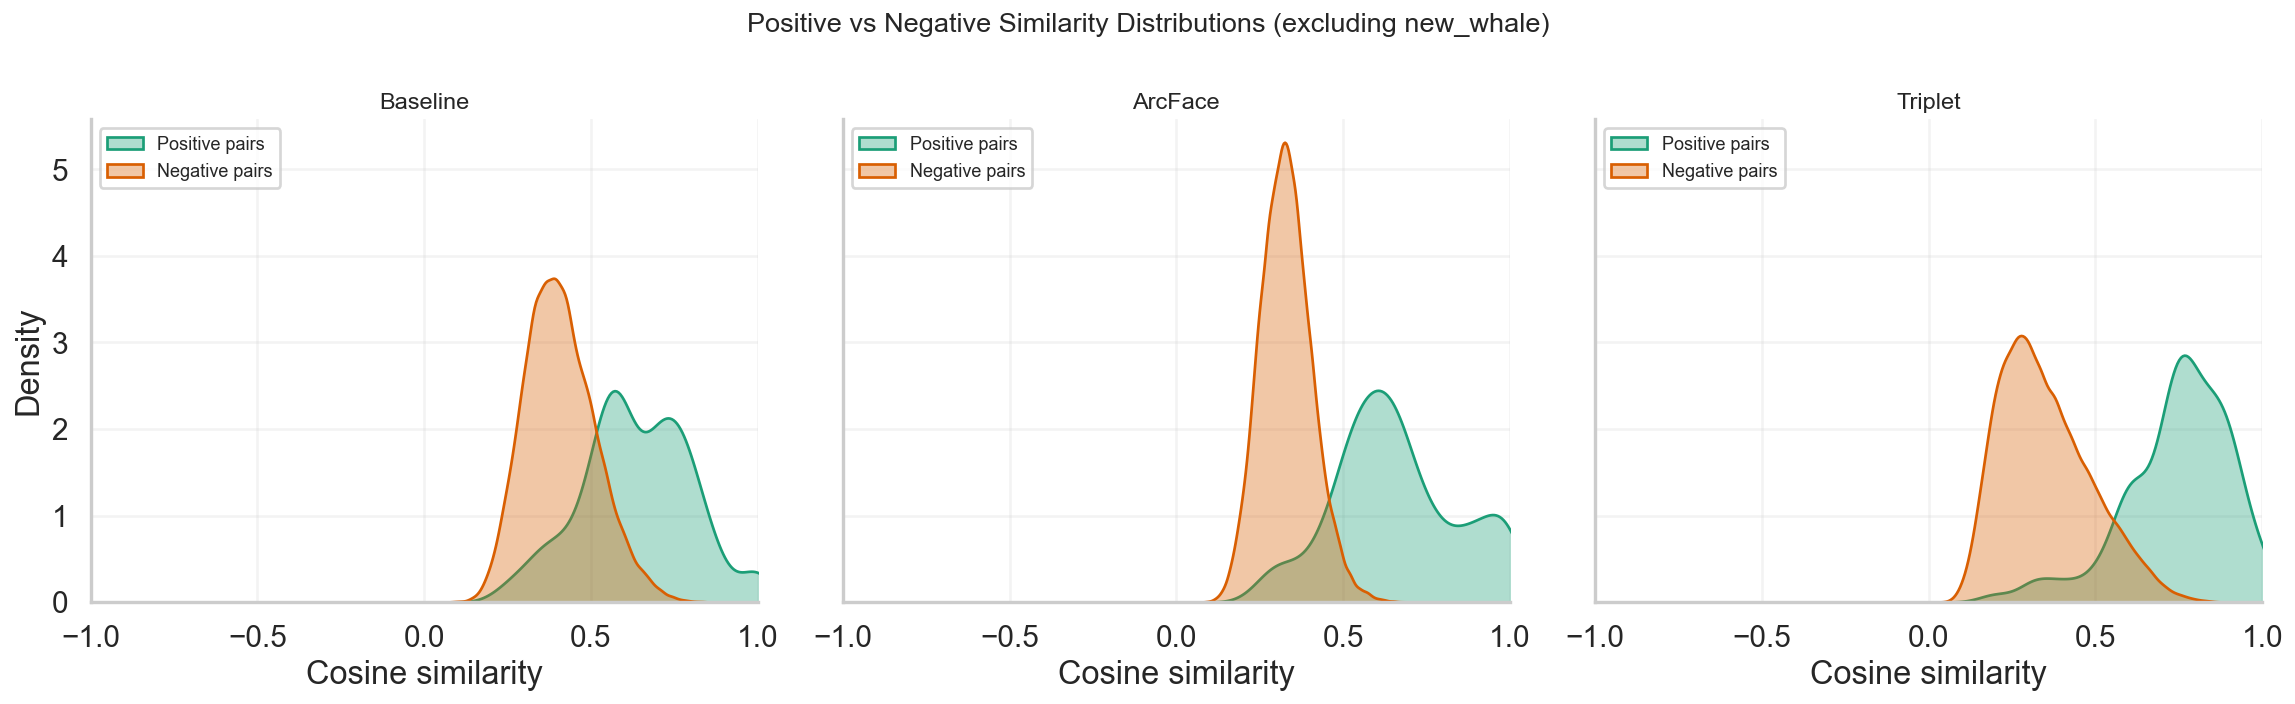

In [15]:
embeddings_by_model = {}
for model_name in ["Baseline", "ArcFace", "Triplet"]:
    model = models_dict.get(model_name)
    if model is None:
        print(f"[skip] {model_name}: model unavailable for embedding extraction.")
        continue
    emb, labels = extract_embeddings(model, query_loader, device, normalize=True)
    embeddings_by_model[model_name] = {"embeddings": emb, "labels": labels}
    print(f"{model_name}: extracted {len(labels)} validation embeddings.")


def pair_similarity_distributions(emb_t, labels_t, max_positive=60000, max_negative=60000, seed=42):
    rng = np.random.default_rng(seed)

    emb = emb_t.cpu().numpy().astype(np.float32)
    labels = labels_t.cpu().numpy().astype(np.int64)

    known = labels >= 0  # exclude new_whale for this analysis
    emb = emb[known]
    labels = labels[known]

    if len(emb) < 2:
        return np.array([]), np.array([])

    unique_classes = np.unique(labels)

    positives = []
    per_class_budget = max(20, max_positive // max(len(unique_classes), 1))

    for c in unique_classes:
        idx = np.where(labels == c)[0]
        if len(idx) < 2:
            continue

        n_pairs = min(per_class_budget, len(idx) * 4)
        a = rng.choice(idx, size=n_pairs, replace=True)
        b = rng.choice(idx, size=n_pairs, replace=True)
        valid = a != b
        if np.any(valid):
            sims = np.sum(emb[a[valid]] * emb[b[valid]], axis=1)
            positives.append(sims)

    positive_sims = np.concatenate(positives) if positives else np.array([])
    if len(positive_sims) > max_positive:
        take = rng.choice(len(positive_sims), size=max_positive, replace=False)
        positive_sims = positive_sims[take]

    negative_sims = []
    n = len(labels)
    attempts = 0
    while len(negative_sims) < max_negative and attempts < max_negative * 20:
        batch = min(4000, max_negative - len(negative_sims))
        a = rng.integers(0, n, size=batch)
        b = rng.integers(0, n, size=batch)
        valid = labels[a] != labels[b]
        if np.any(valid):
            sims = np.sum(emb[a[valid]] * emb[b[valid]], axis=1)
            negative_sims.extend(sims.tolist())
        attempts += 1

    negative_sims = np.array(negative_sims[:max_negative], dtype=np.float32)
    return positive_sims, negative_sims


fig, axes = plt.subplots(1, 3, figsize=(18, 5.6), sharex=True, sharey=True)
for i, model_name in enumerate(["Baseline", "ArcFace", "Triplet"]):
    ax = axes[i]
    payload = embeddings_by_model.get(model_name)

    if payload is None:
        ax.set_title(f"{model_name} (missing)")
        ax.axis("off")
        continue

    pos_sims, neg_sims = pair_similarity_distributions(
        payload["embeddings"], payload["labels"], seed=42 + i
    )

    if len(pos_sims) > 0:
        sns.kdeplot(pos_sims, ax=ax, fill=True, alpha=0.35, color="#1b9e77", label="Positive pairs")
    if len(neg_sims) > 0:
        sns.kdeplot(neg_sims, ax=ax, fill=True, alpha=0.35, color="#d95f02", label="Negative pairs")

    ax.set_title(model_name, fontsize=13)
    ax.set_xlabel("Cosine similarity")
    ax.set_xlim(-1.0, 1.0)
    ax.grid(alpha=0.22)
    if i == 0:
        ax.set_ylabel("Density")
    ax.legend(loc="upper left", fontsize=10)

fig.suptitle("Positive vs Negative Similarity Distributions (excluding new_whale)", fontsize=15)
plt.tight_layout()
plt.show()

#### Code Block: Define Reusable t-SNE Helper Function

This helper mirrors the notebook-2 style t-SNE settings and is kept as a reusable utility for optional single-model visualizations.

In [16]:
def plot_embedding_tsne(
    model,
    loader,
    data,
    device,
    title="",
    max_samples=700,
    top_k_classes=10,
    min_samples_per_class=5,
    combine_loaders=None,
    show_legend=False,
):
    """Notebook-2 style t-SNE with optional loader pooling and density-focused plotting."""
    if model is None:
        print(f"[skip] {title}: model is missing.")
        return

    # Primary embeddings
    all_emb, all_lab = extract_embeddings(model, loader, device)

    # Optional pooled embeddings (e.g., train loader) for denser clusters
    if combine_loaders:
        for extra_loader in combine_loaders:
            e, l = extract_embeddings(model, extra_loader, device)
            all_emb = torch.cat([all_emb, e], dim=0)
            all_lab = torch.cat([all_lab, l], dim=0)

    known_mask = all_lab >= 0
    emb = all_emb[known_mask].cpu().numpy()
    lab = all_lab[known_mask].cpu().numpy()

    if len(emb) < 30:
        print(f"[skip] {title}: too few known samples for t-SNE.")
        return

    unique, counts = np.unique(lab, return_counts=True)
    frequent = unique[counts >= min_samples_per_class]
    if len(frequent) == 0:
        frequent = unique[counts >= 2]
    if len(frequent) == 0:
        print(f"[skip] {title}: no classes with enough samples.")
        return

    freq_counts = {c: int(counts[unique == c][0]) for c in frequent}
    top_classes = sorted(freq_counts, key=freq_counts.get, reverse=True)[:top_k_classes]

    class_mask = np.isin(lab, top_classes)
    emb = emb[class_mask]
    lab = lab[class_mask]

    if len(emb) > max_samples:
        rng = np.random.default_rng(42)
        idx = rng.choice(len(emb), size=max_samples, replace=False)
        emb = emb[idx]
        lab = lab[idx]

    n_points = len(emb)
    n_classes = len(np.unique(lab))
    if n_classes < 2:
        print(f"[skip] {title}: need at least 2 classes after filtering.")
        return

    perplexity = min(max(n_points // 8, 5), 50)
    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        random_state=42,
        max_iter=1500,
        init="pca",
        learning_rate="auto",
    )
    emb_2d = tsne.fit_transform(emb)

    fig, ax = plt.subplots(1, 1, figsize=(9.5, 9.0))
    cmap = plt.get_cmap("tab10" if n_classes <= 10 else "tab20")
    classes_sorted = sorted(np.unique(lab))

    for i, c in enumerate(classes_sorted):
        mask = lab == c
        color = cmap(i % cmap.N)
        whale_name = data["idx_to_id"].get(int(c), str(c))[:12]
        count = int(mask.sum())

        ax.scatter(
            emb_2d[mask, 0],
            emb_2d[mask, 1],
            s=24,
            alpha=0.55,
            color=color,
            edgecolors="none",
            label=f"{whale_name} ({count})",
        )

    ax.set_title(title, fontsize=14, pad=10)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

    if show_legend:
        ax.legend(
            fontsize=7,
            markerscale=1.2,
            loc="upper left",
            bbox_to_anchor=(1.01, 1),
            frameon=True,
            framealpha=0.9,
        )

    plt.tight_layout()
    plt.show()

    print(f"t-SNE points: {n_points}, classes: {n_classes}, perplexity: {perplexity}")

### Interpretation Guide: Side-by-side t-SNE with Fixed Class Colors

Goal:
- Compare Baseline, ArcFace, and Triplet cluster geometry in one figure.
- Keep the same class-color mapping across all panels.

How to read this comparison:
- Tight, isolated blobs suggest stronger local class compactness.
- Diffuse/overlapping regions suggest weaker separation.
- Relative class placement across panels is not directly comparable (t-SNE is non-linear), but per-model cluster compactness is.

Notes for next AI reviewer:
- If one model forms compact clusters for the same color classes while another is diffuse, this supports embedding-quality differences.
- If class colors collapse similarly across all models, downstream gains likely come from thresholding/ranking details rather than geometry.

#### Code Block: Generate Side-by-side t-SNE and Color Ledger

Whale ID <-> color ledger (shared across all t-SNE panels):


,class_idx,whale_id,color_hex,train_count,val_count
0,309,w_1287fbc,#1f77b4,24,9
1,1950,w_7554f44,#ff7f0e,21,5
2,2579,w_98baff9,#2ca02c,22,2
3,2858,w_ab4cae2,#d62728,21,1
4,497,w_1eafe46,#9467bd,18,3
5,1117,w_43be268,#8c564b,19,1
6,1922,w_73d5489,#e377c2,15,4
7,4193,w_fd1cb9d,#7f7f7f,17,2
8,1738,w_693c9ee,#bcbd22,18,1
9,2510,w_95874a5,#17becf,18,0


c:\Users\krios\Documents\Kode\Unibo\ML4CV\.venv\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


  Extracting embeddings:   0%|          | 0/24 [00:12<?, ?it/s]

  Extracting embeddings:   0%|          | 0/338 [00:12<?, ?it/s]

  Extracting embeddings:   0%|          | 0/24 [00:07<?, ?it/s]

  Extracting embeddings:   0%|          | 0/338 [00:07<?, ?it/s]

  Extracting embeddings:   0%|          | 0/24 [00:07<?, ?it/s]

  Extracting embeddings:   0%|          | 0/338 [00:06<?, ?it/s]

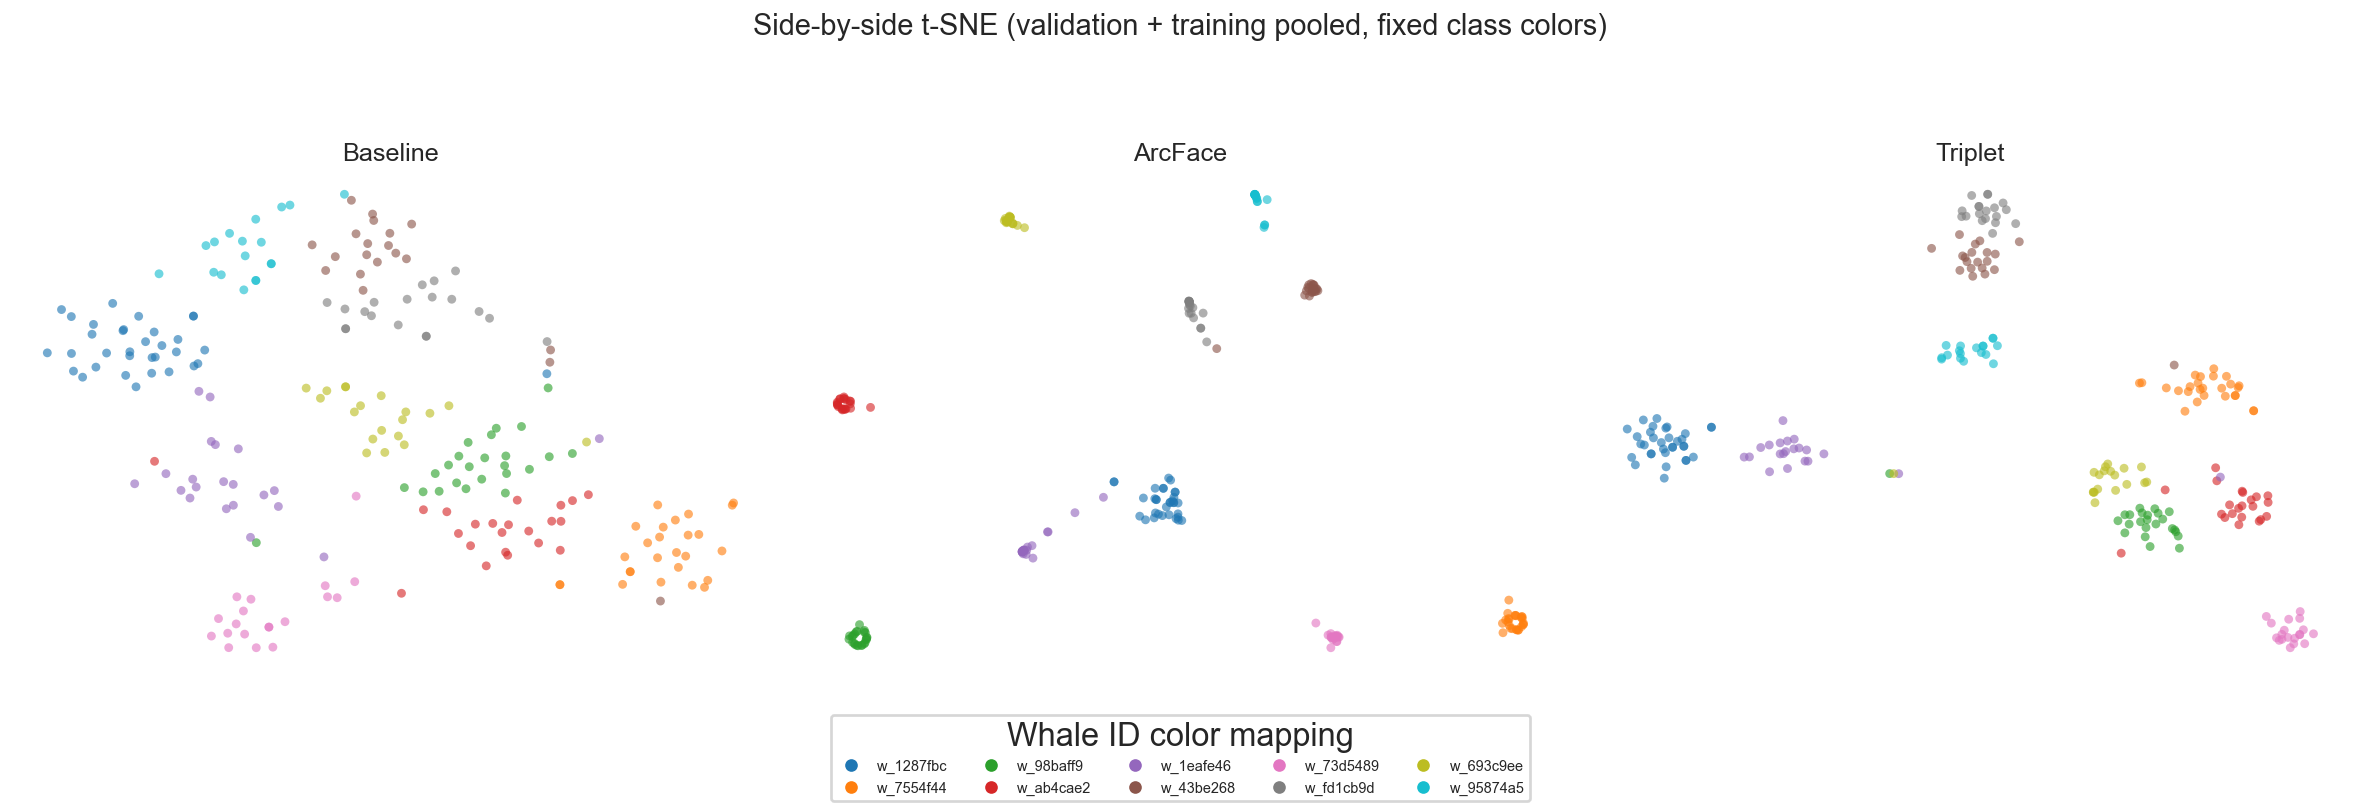

In [17]:
from matplotlib.lines import Line2D
from matplotlib import colors as mcolors


def collect_pooled_known_embeddings(model, base_loader, extra_loaders, device):
    if model is None:
        return None, None

    emb, lab = extract_embeddings(model, base_loader, device)
    for extra_loader in extra_loaders:
        e, l = extract_embeddings(model, extra_loader, device)
        emb = torch.cat([emb, e], dim=0)
        lab = torch.cat([lab, l], dim=0)

    known = lab >= 0
    return emb[known].cpu().numpy(), lab[known].cpu().numpy()


# Use the same top classes and the same colors across all model panels
combined_df = pd.concat([data["train_df"], data["val_df"]], axis=0, ignore_index=True)
combined_known = combined_df[combined_df["Id"].isin(data["id_to_idx"])]

top_whale_ids = combined_known["Id"].value_counts().head(10).index.tolist()
top_class_indices = [data["id_to_idx"][wid] for wid in top_whale_ids if wid in data["id_to_idx"]]

if len(top_class_indices) < 2:
    raise RuntimeError("Need at least 2 classes for side-by-side t-SNE visualization.")

palette = plt.get_cmap("tab10" if len(top_class_indices) <= 10 else "tab20")
class_to_color = {cls: palette(i % palette.N) for i, cls in enumerate(top_class_indices)}
class_to_name = {cls: data["idx_to_id"].get(int(cls), str(cls)) for cls in top_class_indices}

ledger_rows = []
for cls in top_class_indices:
    whale_id = class_to_name[cls]
    ledger_rows.append({
        "class_idx": int(cls),
        "whale_id": whale_id,
        "color_hex": mcolors.to_hex(class_to_color[cls]),
        "train_count": int((data["train_df"]["Id"] == whale_id).sum()),
        "val_count": int((data["val_df"]["Id"] == whale_id).sum()),
    })

color_ledger_df = pd.DataFrame(ledger_rows)
print("Whale ID <-> color ledger (shared across all t-SNE panels):")
display(color_ledger_df)

pooled_embeddings = {}
for model_name in ["Baseline", "ArcFace", "Triplet"]:
    model = models_dict.get(model_name)
    emb_np, lab_np = collect_pooled_known_embeddings(
        model,
        query_loader,
        extra_loaders=[gallery_loader],
        device=device,
    )
    pooled_embeddings[model_name] = (emb_np, lab_np)

fig, axes = plt.subplots(1, 3, figsize=(18.5, 6.2))
rng = np.random.default_rng(42)
max_per_class = 36

for ax, model_name in zip(axes, ["Baseline", "ArcFace", "Triplet"]):
    emb_np, lab_np = pooled_embeddings.get(model_name, (None, None))

    if emb_np is None or lab_np is None or len(emb_np) == 0:
        ax.set_title(f"{model_name} (missing)")
        ax.axis("off")
        continue

    keep_mask = np.isin(lab_np, top_class_indices)
    emb_f = emb_np[keep_mask]
    lab_f = lab_np[keep_mask]

    sampled_idx = []
    for cls in top_class_indices:
        cls_idx = np.where(lab_f == cls)[0]
        if len(cls_idx) == 0:
            continue
        take = min(len(cls_idx), max_per_class)
        sampled_idx.extend(rng.choice(cls_idx, size=take, replace=False).tolist())

    if len(sampled_idx) < 30:
        ax.set_title(f"{model_name} (insufficient points)")
        ax.axis("off")
        continue

    sampled_idx = np.array(sampled_idx, dtype=int)
    emb_s = emb_f[sampled_idx]
    lab_s = lab_f[sampled_idx]

    perplexity = min(max(len(emb_s) // 8, 5), 50)
    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        random_state=42,
        max_iter=1500,
        init="pca",
        learning_rate="auto",
    )
    emb_2d = tsne.fit_transform(emb_s)

    for cls in top_class_indices:
        mask = lab_s == cls
        if not np.any(mask):
            continue
        ax.scatter(
            emb_2d[mask, 0],
            emb_2d[mask, 1],
            s=24,
            alpha=0.62,
            color=class_to_color[cls],
            edgecolors="none",
        )

    ax.set_title(model_name, fontsize=14)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="",
        markersize=7,
        markerfacecolor=class_to_color[cls],
        markeredgecolor="none",
        label=class_to_name[cls],
    )
    for cls in top_class_indices
]

fig.suptitle("Side-by-side t-SNE (validation + training pooled, fixed class colors)", fontsize=16)
fig.legend(
    handles=handles,
    loc="lower center",
    ncol=min(5, len(handles)),
    frameon=True,
    fontsize=8,
    title="Whale ID color mapping",
)
plt.tight_layout(rect=[0, 0.12, 1, 0.94])
plt.show()

## Section 7: Rigorous Open-Set Protocol for New Whale

### Closed-set vs Open-set
- **Closed-set**: every query is assumed to belong to one of the known trained identities.
- **Open-set**: queries may include unseen identities (`new_whale`), so the system must both identify known whales and reject unknowns.

### Why threshold-free metrics matter
- `closed_set_recall@1` and `closed_set_recall@5` are **threshold-free**: they evaluate ranking quality assuming no reject option.
- They are useful as upper-bound ranking diagnostics but cannot evaluate unknown rejection behavior.

### Why thresholded metrics matter
- Open-set decision uses a reject rule based on max similarity.
- Threshold controls the trade-off:
  - Lower threshold: fewer rejections, higher known recall, weaker unknown detection.
  - Higher threshold: more rejections, stronger unknown detection, risk of rejecting known whales.

### Alternative open-set strategies (not implemented here)
1. Global threshold (current baseline approach)
2. Model-specific threshold (implemented)
3. Per-k threshold (`k=1` vs `k=5`, implemented)
4. Class-conditional thresholds (per-identity)
5. Calibrated confidence/energy scores (temperature scaling, energy-based OOD)
6. Conformal prediction / selective classification with coverage guarantees

### How to read upcoming plots
- **Closed-set bar plot**: ranking quality independent of reject threshold.
- **Threshold sweep**: objective landscape over thresholds; selected vertical lines are operating points.
- **ROC curve**: threshold-agnostic separability of known vs unknown scores.
  - Higher AUC means better score ordering, not necessarily better thresholded operating point.
- **Known vs New KDE**: visual overlap of score distributions; less overlap generally means easier thresholding.

Notes for next AI reviewer:
- If AUC is moderate but thresholded metrics differ strongly across models, operating-point choice is likely dominating outcomes.
- If curves are flat around best thresholds, deployment is robust; if steep, threshold sensitivity is high and needs careful reporting.

This section makes threshold choice an explicit optimization problem instead of a fixed heuristic.

#### Code Block: Build Closed-set Rankings and Threshold-free Metrics

### Interpretation Guide: Threshold Search, ROC, and Score Distributions

What the next block produces:
- Threshold selection tables (calibration split)
- Held-out evaluation metrics at selected thresholds
- Threshold sweep curves (`k=1`, `k=5`)
- ROC curves and score KDE plots

How to interpret threshold sweeps:
- Peak of the objective curve marks the selected operating point for that objective.
- Dashed/dotted curves show how known-recall and new-recall co-move with threshold.
- Divergence between `k=1` and `k=5` selected thresholds is expected.

How to interpret ROC:
- ROC summarizes score ordering quality across all thresholds.
- AUC near 0.5 means poor separability; higher AUC means better ranking of known vs unknown.

Notes for next AI reviewer:
- If selected thresholds differ strongly across splits, calibration may be unstable.
- If ROC improves but thresholded metrics do not, objective choice (or class priors) may be mismatched.
- If KDE overlap is high, report uncertainty around threshold-dependent claims.

#### Code Block: Calibrate Thresholds and Plot Open-set Curves

Selected thresholds (k=1 and k=5 can and usually should differ):


,model,k,objective,selected_threshold,calibration_objective_value,calibration_overall_acc_at_k,calibration_map_at_k,calibration_known_recall_at_k,calibration_new_recall,calibration_new_whale_f1
0,Baseline,1,maximize overall_acc_at_k,0.724225,0.453237,0.453237,0.453237,0.502146,0.200000,0.216867
1,Baseline,5,maximize map_at_k,0.766177,0.498501,0.586331,0.498501,0.622318,0.400000,0.270677
2,ArcFace,1,maximize overall_acc_at_k,0.623264,0.629496,0.629496,0.629496,0.725322,0.133333,0.184615
3,ArcFace,5,maximize map_at_k,0.698776,0.663010,0.769784,0.663010,0.819742,0.511111,0.304636
4,Triplet,1,maximize overall_acc_at_k,0.782073,0.579137,0.579137,0.579137,0.665236,0.133333,0.179104
5,Triplet,5,maximize map_at_k,0.838640,0.626319,0.719424,0.626319,0.793991,0.333333,0.243902


Held-out evaluation metrics at selected thresholds:


,model,k,threshold,overall_acc_at_k,map_at_k,known_recall_at_k,new_recall,new_whale_f1,known_reject_rate,open_set_auc,n_known,n_new
2,ArcFace,1,0.623264,0.594982,0.594982,0.670940,0.200000,0.216867,0.123932,0.555793,234,45
0,Baseline,1,0.724225,0.422939,0.422939,0.461538,0.222222,0.190476,0.213675,0.483286,234,45
4,Triplet,1,0.782073,0.541219,0.541219,0.636752,0.044444,0.054054,0.115385,0.507930,234,45
3,ArcFace,5,0.698776,0.720430,0.634349,0.752137,0.555556,0.314465,0.380342,0.555793,234,45
1,Baseline,5,0.766177,0.548387,0.457407,0.581197,0.377778,0.222222,0.388889,0.483286,234,45
5,Triplet,5,0.838640,0.666667,0.589665,0.730769,0.333333,0.222222,0.320513,0.507930,234,45


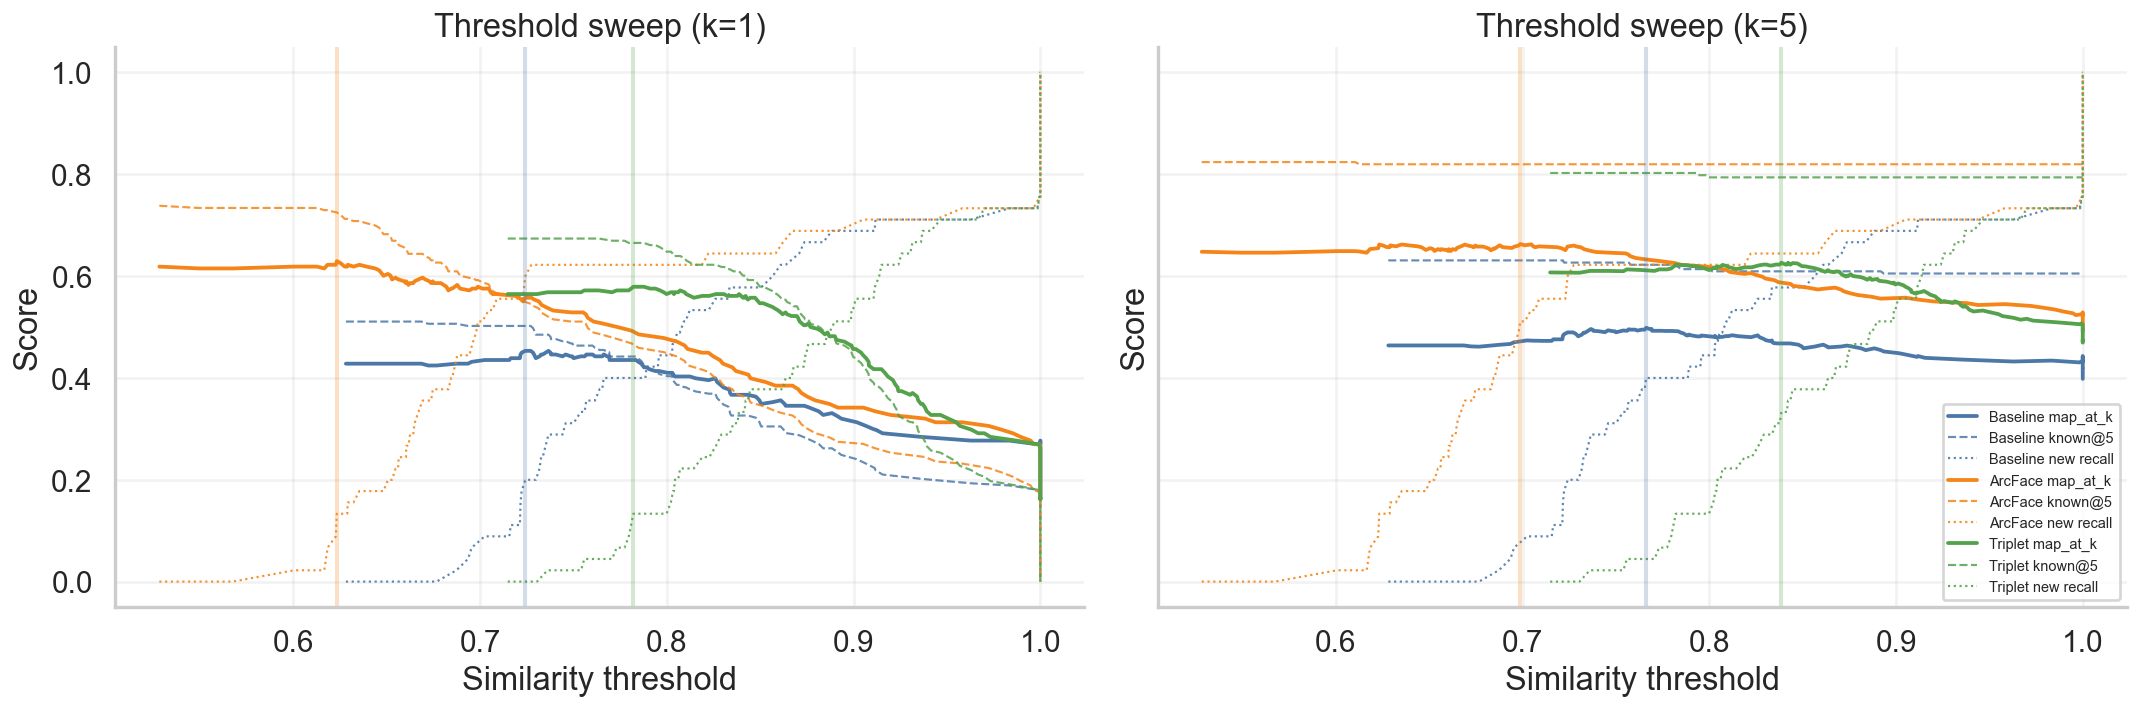

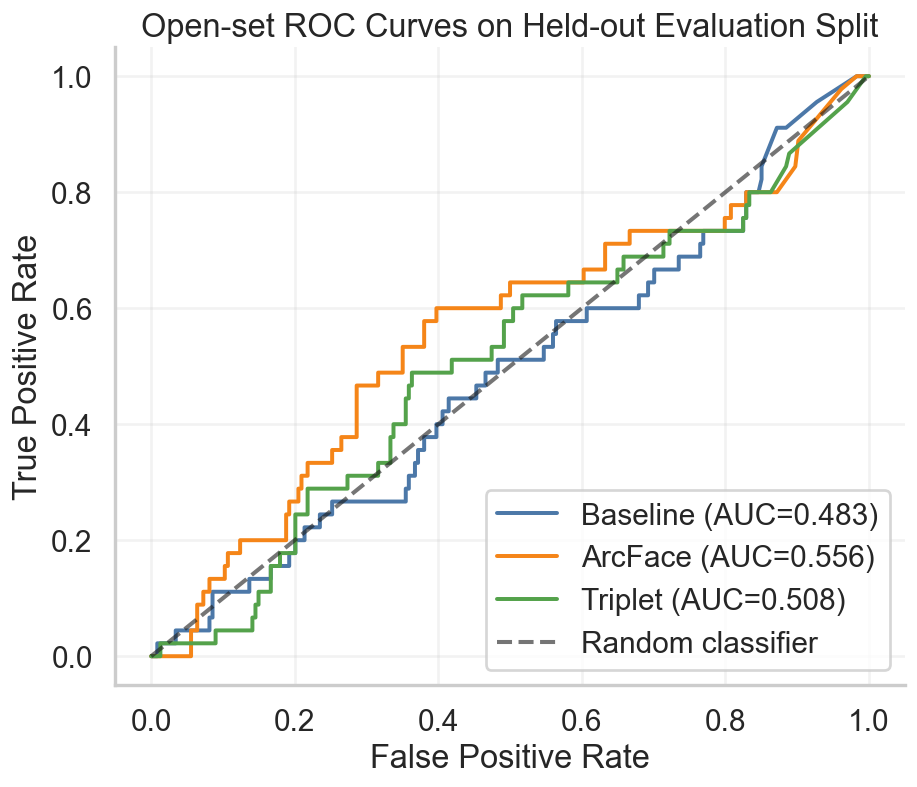

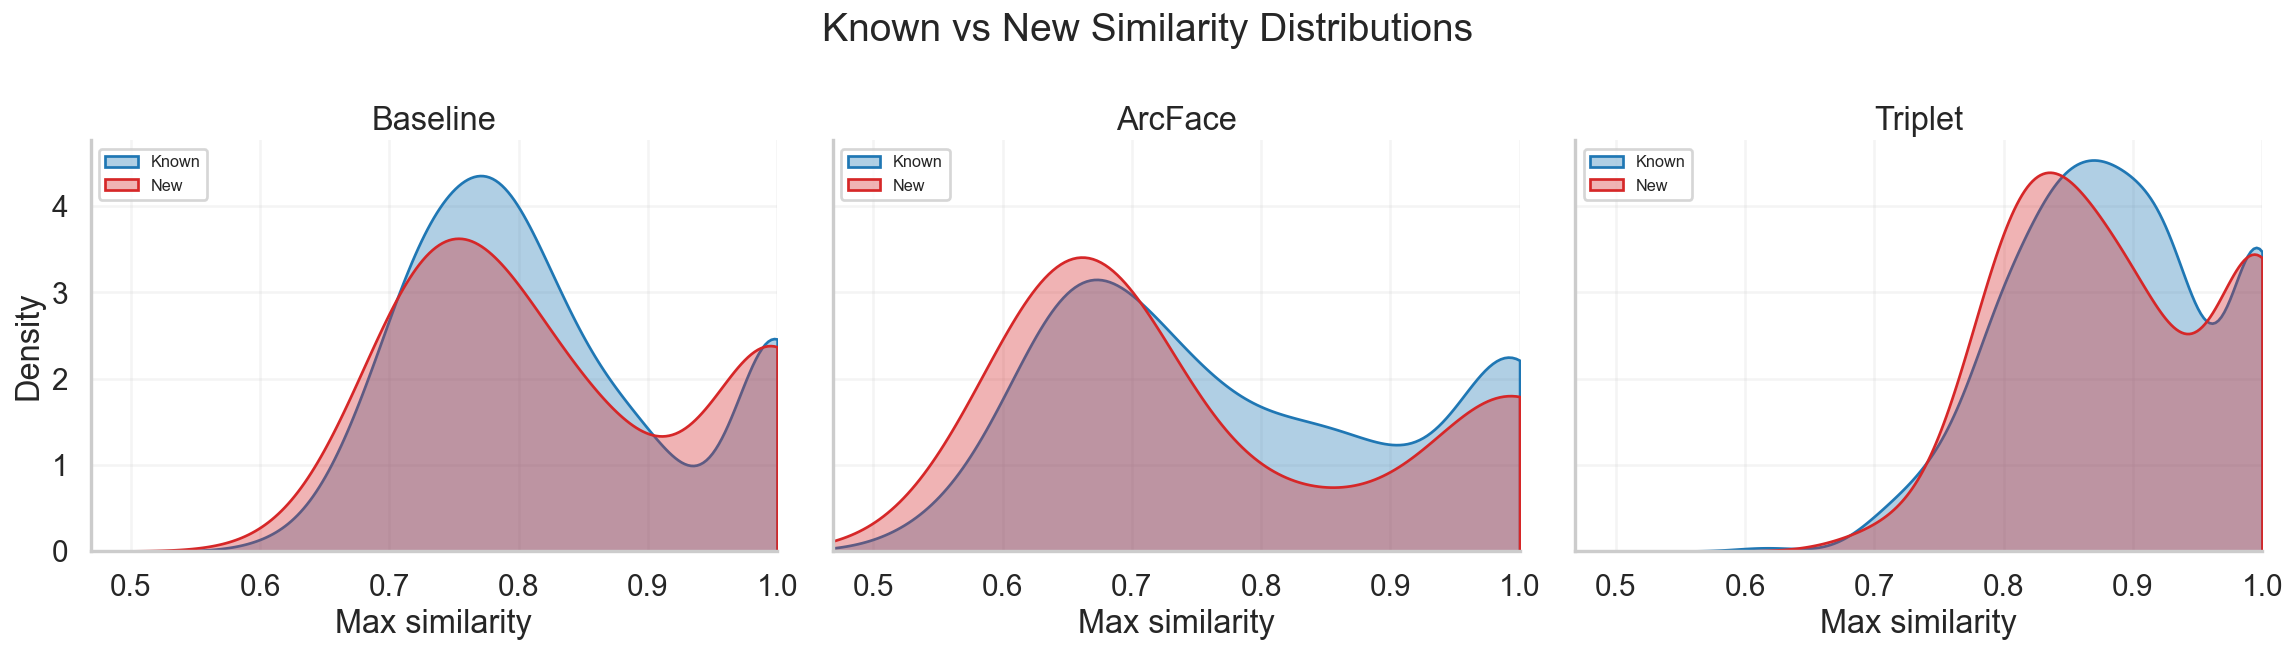

In [30]:
def compute_map_at_k(rank_df, k, threshold):
    if rank_df is None or len(rank_df) == 0:
        return np.nan

    ap_scores = []
    for _, row in rank_df.iterrows():
        pred = _apply_reject_rule(row["top_labels"], row["max_similarity"], k, threshold)
        true_label = int(row["true_label"])
        if true_label in pred:
            rank = pred.index(true_label) + 1
            ap_scores.append(1.0 / rank)
        else:
            ap_scores.append(0.0)

    return float(np.mean(ap_scores)) if len(ap_scores) > 0 else np.nan


# Calibrate thresholds per model and per k on calibration split, then report on held-out eval split
calibration_rows = []
selected_metrics_rows = []
curve_rows = []
roc_payload = {}

for model_name in ["Baseline", "ArcFace", "Triplet"]:
    rank_df = ranking_by_model.get(model_name)
    if rank_df is None or len(rank_df) == 0:
        continue

    calib_df, eval_df = stratified_calibration_split(rank_df, calib_frac=0.5, seed=42)
    if len(calib_df) == 0 or len(eval_df) == 0:
        print(f"[skip] {model_name}: not enough data for calibration/eval split.")
        continue

    threshold_grid = build_threshold_grid(calib_df["max_similarity"].values, n=140)

    for k in [1, 5]:
        sweep_df = sweep_thresholds(calib_df, k, threshold_grid)
        sweep_df["map_at_k"] = [compute_map_at_k(calib_df, k, t) for t in sweep_df["threshold"]]
        sweep_df["model"] = model_name
        sweep_df["split"] = "calibration"
        curve_rows.append(sweep_df)

        # Objective choice:
        # - k=1: optimize overall open-set accuracy@1
        # - k=5: optimize MAP@5-like ranking quality (prevents trivial always-reject solutions)
        objective_col = "overall_acc_at_k" if k == 1 else "map_at_k"
        best_idx = sweep_df[objective_col].idxmax()
        best_row = sweep_df.loc[best_idx]
        tau_star = float(best_row["threshold"])

        calibration_rows.append({
            "model": model_name,
            "k": k,
            "objective": f"maximize {objective_col}",
            "selected_threshold": tau_star,
            "calibration_objective_value": float(best_row[objective_col]),
            "calibration_overall_acc_at_k": float(best_row["overall_acc_at_k"]),
            "calibration_map_at_k": float(best_row["map_at_k"]),
            "calibration_known_recall_at_k": float(best_row["known_recall_at_k"]),
            "calibration_new_recall": float(best_row["new_recall"]),
            "calibration_new_whale_f1": float(best_row["new_whale_f1"]),
        })

        eval_metrics = evaluate_open_set_at_k(eval_df, k, tau_star)
        eval_metrics["map_at_k"] = compute_map_at_k(eval_df, k, tau_star)
        eval_metrics["model"] = model_name
        eval_metrics["split"] = "evaluation"
        selected_metrics_rows.append(eval_metrics)

    # ROC data on evaluation split (threshold-free ranking score)
    y_true_new = (~eval_df["is_known"]).astype(int).values
    y_score_new = -eval_df["max_similarity"].values
    if len(np.unique(y_true_new)) >= 2:
        fpr, tpr, _ = roc_curve(y_true_new, y_score_new)
        roc_payload[model_name] = {
            "fpr": fpr,
            "tpr": tpr,
            "auc": auc(fpr, tpr),
        }

calibration_df = pd.DataFrame(calibration_rows)
selected_eval_df = pd.DataFrame(selected_metrics_rows)
curves_df = pd.concat(curve_rows, axis=0, ignore_index=True) if len(curve_rows) > 0 else pd.DataFrame()

print("Selected thresholds (k=1 and k=5 can and usually should differ):")
display(calibration_df)

print("Held-out evaluation metrics at selected thresholds:")
if not selected_eval_df.empty:
    display(
        selected_eval_df[[
            "model",
            "k",
            "threshold",
            "overall_acc_at_k",
            "map_at_k",
            "known_recall_at_k",
            "new_recall",
            "new_whale_f1",
            "known_reject_rate",
            "open_set_auc",
            "n_known",
            "n_new",
        ]].sort_values(["k", "model"])
    )

# Threshold sweep plots (calibration split)
if not curves_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(16.8, 5.8), sharey=True)
    colors = {"Baseline": "#4C78A8", "ArcFace": "#F58518", "Triplet": "#54A24B"}

    for j, k in enumerate([1, 5]):
        ax = axes[j]
        k_df = curves_df[curves_df["k"] == k]
        for model_name in ["Baseline", "ArcFace", "Triplet"]:
            m_df = k_df[k_df["model"] == model_name]
            if len(m_df) == 0:
                continue

            primary_metric = "overall_acc_at_k" if k == 1 else "map_at_k"
            ax.plot(
                m_df["threshold"],
                m_df[primary_metric],
                color=colors.get(model_name, None),
                linewidth=2.1,
                label=f"{model_name} {primary_metric}",
            )
            ax.plot(
                m_df["threshold"],
                m_df["known_recall_at_k"],
                color=colors.get(model_name, None),
                linewidth=1.2,
                linestyle="--",
                alpha=0.85,
                label=f"{model_name} known@{k}",
            )
            ax.plot(
                m_df["threshold"],
                m_df["new_recall"],
                color=colors.get(model_name, None),
                linewidth=1.2,
                linestyle=":",
                alpha=0.9,
                label=f"{model_name} new recall",
            )

        # Mark selected thresholds for this k
        k_sel = calibration_df[calibration_df["k"] == k]
        for _, row in k_sel.iterrows():
            ax.axvline(row["selected_threshold"], color=colors.get(row["model"], "gray"), alpha=0.25)

        ax.set_title(f"Threshold sweep (k={k})")
        ax.set_xlabel("Similarity threshold")
        ax.set_ylabel("Score")
        ax.grid(alpha=0.25)

    handles, labels = axes[1].get_legend_handles_labels()
    uniq = dict(zip(labels, handles))
    axes[1].legend(uniq.values(), uniq.keys(), fontsize=8, frameon=True, loc="best")
    plt.tight_layout()
    plt.savefig('img/threshold_sweep.png', bbox_inches='tight', dpi=300)
    plt.show()

# ROC curves on held-out eval split
if roc_payload:
    plt.figure(figsize=(7.4, 6.4))
    colors = {"Baseline": "#4C78A8", "ArcFace": "#F58518", "Triplet": "#54A24B"}
    for model_name in ["Baseline", "ArcFace", "Triplet"]:
        payload = roc_payload.get(model_name)
        if payload is None:
            continue
        plt.plot(
            payload["fpr"],
            payload["tpr"],
            linewidth=2.2,
            color=colors.get(model_name, None),
            label=f"{model_name} (AUC={payload['auc']:.3f})",
        )
    plt.plot([0, 1], [0, 1], "k--", alpha=0.6, label="Random classifier")
    plt.title("Open-set ROC Curves on Held-out Evaluation Split")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.grid(alpha=0.25)
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

# Score distributions (known vs new) per model for interpretability
fig, axes = plt.subplots(1, 3, figsize=(18, 5.2), sharex=True, sharey=True)
for i, model_name in enumerate(["Baseline", "ArcFace", "Triplet"]):
    ax = axes[i]
    rank_df = ranking_by_model.get(model_name)
    if rank_df is None or len(rank_df) == 0:
        ax.set_title(f"{model_name} (missing)")
        ax.axis("off")
        continue

    known_scores = rank_df.loc[rank_df["is_known"], "max_similarity"].values
    new_scores = rank_df.loc[~rank_df["is_known"], "max_similarity"].values

    if len(known_scores) > 1:
        sns.kdeplot(known_scores, ax=ax, fill=True, alpha=0.35, color="#1f77b4", label="Known", cut=3, clip=(-np.inf, 1.0))
    if len(new_scores) > 1:
        sns.kdeplot(new_scores, ax=ax, fill=True, alpha=0.35, color="#d62728", label="New", cut=3, clip=(-np.inf, 1.0))

    ax.set_title(model_name)
    ax.set_xlabel("Max similarity")
    ax.set_xlim(right=1.0)
    ax.grid(alpha=0.2)
    if i == 0:
        ax.set_ylabel("Density")
    ax.legend(loc="upper left", fontsize=9)

plt.suptitle("Known vs New Similarity Distributions")
plt.tight_layout()
plt.savefig('img/kde_overlap.png', bbox_inches='tight', dpi=300)
plt.show()